In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/SOP/data without infertility _final.csv'
df = pd.read_csv(file_path, encoding='latin1')

df.head()

,Sl No,Patient File No,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg Exercise(Y/N),BP Systolic (mmHg),BP Diastolic (mmHg),Follicle No (L),Follicle No (R),Avg F size (L) (mm),Avg F size (R) (mm),Insulin levels (æIU/ml),Endometrium (mm)
0,1,10001,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,7,8.5
1,2,10002,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,10,3.7
2,3,10003,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,23,10.0
3,4,10004,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,10,7.5
4,5,10005,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,14,7.0


In [3]:
# Estadísticas basica
print(df.describe())

            Sl No  Patient File No  PCOS (Y/N)   Age (yrs)  Weight (Kg)  \
count  541.000000       541.000000  541.000000  541.000000   541.000000   
mean   271.000000     10271.000000    0.327172   31.430684    59.637153   
std    156.317519       156.317519    0.469615    5.411006    11.028287   
min      1.000000     10001.000000    0.000000   20.000000    31.000000   
25%    136.000000     10136.000000    0.000000   28.000000    52.000000   
50%    271.000000     10271.000000    0.000000   31.000000    59.000000   
75%    406.000000     10406.000000    1.000000   35.000000    65.000000   
max    541.000000     10541.000000    1.000000   48.000000   108.000000   

       Height(Cm)          BMI  Blood Group  Pulse rate(bpm)   \
count   541.000000  541.000000   541.000000        541.000000   
mean    156.484835   24.311285    13.802218         73.247689   
std       6.033545    4.056399     1.840812          4.430285   
min     137.000000   12.417882    11.000000         13.000000   

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

--- Estadística Descriptiva ---
       Insulin levels (æIU/ml)  Follicle_No_Total  Avg_F_size_Total
count               541.000000         541.000000        541.000000
mean                 14.105360          12.770795         15.234908
std                   6.753736           8.220748          3.004777
min                   1.000000           1.000000          2.900000
25%                   8.000000           6.000000         13.500000
50%                  13.000000          12.000000         15.500000
75%                  21.000000          18.000000         17.500000
max                  30.000000          41.000000         22.000000

--- Correlación de Pearson ---
Insulin levels (æIU/ml)    1.000000
Follicle_No_Total          0.583468
Avg_F_size_Total           0.098570
Name: Insulin levels (æIU/ml), dtype: float64


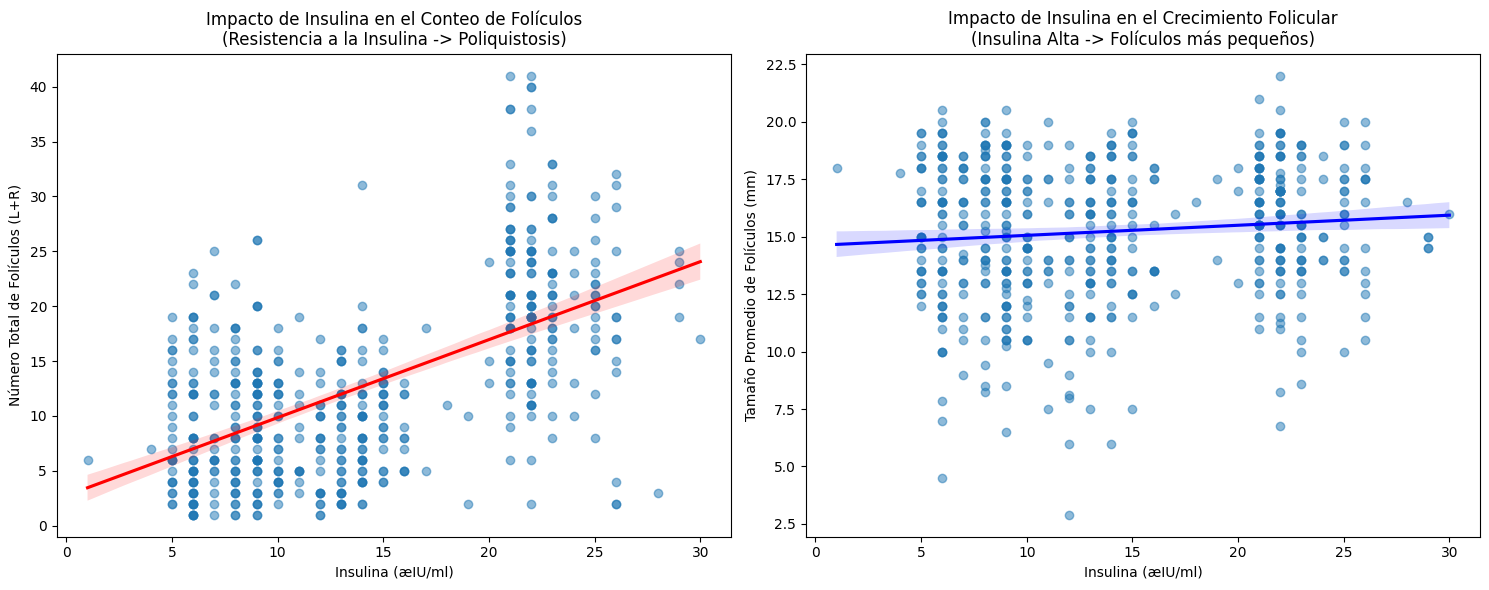

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Carga del archivo desde Drive
file_path = '/content/drive/MyDrive/Colab Notebooks/SOP/data without infertility _final.csv'
df = pd.read_csv(file_path, encoding='latin1')

# 2. Creación de variables combinadas (Ovario Izquierdo + Derecho)
# Sumamos los folículos de ambos lados para una visión reproductiva total
df['Follicle_No_Total'] = df['Follicle No (L)'] + df['Follicle No (R)']

# Promediamos el tamaño de los folículos de ambos lados
df['Avg_F_size_Total'] = (df['Avg F size (L) (mm)'] + df['Avg F size (R) (mm)']) / 2

# 3. Estadística Descriptiva de las variables clave
cols_interes = ['Insulin levels (æIU/ml)', 'Follicle_No_Total', 'Avg_F_size_Total']
print("--- Estadística Descriptiva ---")
print(df[cols_interes].describe())

# 4. Matriz de Correlación
print("\n--- Correlación de Pearson ---")
correlation = df[cols_interes].corr()
print(correlation['Insulin levels (æIU/ml)'])

# 5. Visualización: Relación Metabólica -> Reproductiva
plt.figure(figsize=(15, 6))

# Gráfico 1: Insulina vs Conteo Total de Folículos
plt.subplot(1, 2, 1)
sns.regplot(x='Insulin levels (æIU/ml)', y='Follicle_No_Total', data=df,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Impacto de Insulina en el Conteo de Folículos\n(Resistencia a la Insulina -> Poliquistosis)')
plt.xlabel('Insulina (æIU/ml)')
plt.ylabel('Número Total de Folículos (L+R)')

# Gráfico 2: Insulina vs Tamaño Promedio de Folículos
plt.subplot(1, 2, 2)
sns.regplot(x='Insulin levels (æIU/ml)', y='Avg_F_size_Total', data=df,
            scatter_kws={'alpha':0.5}, line_kws={'color':'blue'})
plt.title('Impacto de Insulina en el Crecimiento Folicular\n(Insulina Alta -> Folículos más pequeños)')
plt.xlabel('Insulina (æIU/ml)')
plt.ylabel('Tamaño Promedio de Folículos (mm)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_10659/4044179152.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PCOS (Y/N)', y='Follicle_No_Total', data=df, palette='Set2')
/tmp/ipykernel_10659/4044179152.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PCOS (Y/N)', y='Insulin levels (æIU/ml)', data=df, palette='Pastel1')


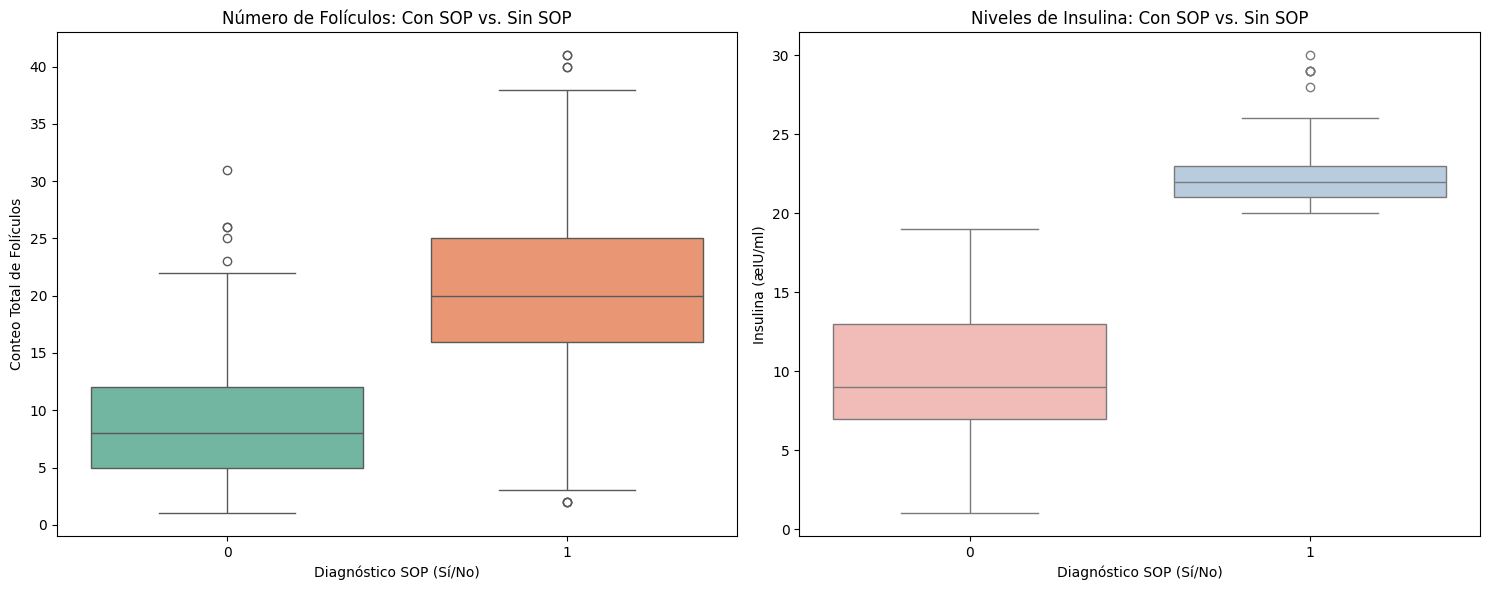

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carga del archivo
file_path = '/content/drive/MyDrive/Colab Notebooks/SOP/data without infertility _final.csv'
df = pd.read_csv(file_path, encoding='latin1')

# 2. Variable combinada
df['Follicle_No_Total'] = df['Follicle No (L)'] + df['Follicle No (R)']

# 3. Configuración de los gráficos
plt.figure(figsize=(15, 6))

# Gráfico 1: Comparación de Folículos entre Grupos
plt.subplot(1, 2, 1)
sns.boxplot(x='PCOS (Y/N)', y='Follicle_No_Total', data=df, palette='Set2')
plt.title('Número de Folículos: Con SOP vs. Sin SOP')
plt.xlabel('Diagnóstico SOP (Sí/No)')
plt.ylabel('Conteo Total de Folículos')

# Gráfico 2: Comparación de Insulina entre Grupos
plt.subplot(1, 2, 2)
sns.boxplot(x='PCOS (Y/N)', y='Insulin levels (æIU/ml)', data=df, palette='Pastel1')
plt.title('Niveles de Insulina: Con SOP vs. Sin SOP')
plt.xlabel('Diagnóstico SOP (Sí/No)')
plt.ylabel('Insulina (æIU/ml)')

plt.tight_layout()
plt.show()

In [8]:
import math
import pandas as pd

df['Total Foliculos'] = df['Follicle No (L)'] + df['Follicle No (R)']

# Fix: Use vectorized operations to create y
y = ((df['Insulin levels (æIU/ml)'] > 14) | (df['Total Foliculos'] > 13)).astype(int).tolist()

# --- 4. Variables ---
columnas = [
    'Insulin levels (æIU/ml)',
    'BMI',
    'Total Foliculos'
]

X = df[columnas].values.tolist()

# --- 5. Distancia ---
def distancia(p1, p2):
    suma = 0
    for i in range(len(p1)):
        suma += (p1[i] - p2[i])**2
    return math.sqrt(suma)

# --- 6. KNN ---
def knn(punto_nuevo, X, y, k=3):
    distancias = []

    for i in range(len(X)):
        d = distancia(punto_nuevo, X[i])
        distancias.append((d, y[i]))

    distancias.sort()
    vecinos = distancias[:k]

    conteo = {}
    for _, clase in vecinos:
        if clase in conteo:
            conteo[clase] += 1
        else:
            conteo[clase] = 1

    clase_final = max(conteo, key=conteo.get)

    return clase_final

# --- 7. Predicciones sobre TODO el dataset ---
y_pred = []

for i in range(len(X)):
    pred = knn(X[i], X, y, k=3)
    y_pred.append(pred)

# --- 8. Matriz de confusión ---
TP = TN = FP = FN = 0

for i in range(len(y)):
    if y[i] == 1 and y_pred[i] == 1:
        TP += 1
    elif y[i] == 0 and y_pred[i] == 0:
        TN += 1
    elif y[i] == 0 and y_pred[i] == 1:
        FP += 1
    elif y[i] == 1 and y_pred[i] == 0:
        FN += 1

# --- 9. Mostrar resultados ---
print("Matriz de Confusión:")
print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

# --- 10. Accuracy ---
accuracy = (TP + TN) / len(y)
print("Accuracy:", accuracy)


Matriz de Confusión:
TP: 268
TN: 262
FP: 3
FN: 8
Accuracy: 0.9796672828096118


In [10]:
import math
import pandas as pd
y = df['PCOS (Y/N)'].tolist()
columnas = [
    'Age (yrs)',
    'Weight (Kg)',
    'BMI',
    'Pulse rate(bpm)',
    'Cycle length(days)',
    'FSH(mIU/mL)',
    'LH(mIU/mL)',
    'FSH/LH',
    'Waist/Hip Ratio',
    'AMH(ng/mL)',
    'PRL(ng/mL)',
    'RBS(mg/dl)',
    'Follicle No (L)',
    'Follicle No (R)',
    'Avg F size (L) (mm)',
    'Avg F size (R) (mm)',
    'Insulin levels (æIU/ml)',
    'Endometrium (mm)'
]

# Convert specified columns to numeric, coercing errors to NaN
# Then fill NaN values with the mean of their respective columns
# This ensures all data points are numerical before distance calculation
for col in columnas:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Matriz de datos
X = df[columnas].values.tolist()


def distancia(p1, p2):

    suma = 0

    for i in range(len(p1)):
        suma += (p1[i] - p2[i])**2

    return math.sqrt(suma)


def knn(punto_nuevo, X, y, k=5):

    distancias = []

    # Calcular distancia con todos los puntos
    for i in range(len(X)):

        d = distancia(punto_nuevo, X[i])

        distancias.append((d, y[i]))

    # Ordenar de menor a mayor distancia
    distancias.sort()

    # Tomar los k vecinos más cercanos
    vecinos = distancias[:k]

    # Contar clases
    conteo = {}

    for _, clase in vecinos:

        if clase in conteo:
            conteo[clase] += 1
        else:
            conteo[clase] = 1

    # Clase final
    clase_final = max(conteo, key=conteo.get)

    return clase_final
#  Predicciones
y_pred = []

for i in range(len(X)):

    pred = knn(X[i], X, y, k=5)

    y_pred.append(pred)


# Matriz de confusión
TP = TN = FP = FN = 0

for i in range(len(y)):

    if y[i] == 1 and y_pred[i] == 1:
        TP += 1

    elif y[i] == 0 and y_pred[i] == 0:
        TN += 1

    elif y[i] == 0 and y_pred[i] == 1:
        FP += 1

    elif y[i] == 1 and y_pred[i] == 0:
        FN += 1


# Resultados


print(" MATRIZ DE CONFUSIÓN ")

print("Verdaderos Positivos (TP):", TP)
print("Verdaderos Negativos (TN):", TN)
print("Falsos Positivos (FP):", FP)
print("Falsos Negativos (FN):", FN)

# 8. Accuracy


accuracy = (TP + TN) / len(y)

print("\nAccuracy:", accuracy)

 MATRIZ DE CONFUSIÓN 
Verdaderos Positivos (TP): 161
Verdaderos Negativos (TN): 363
Falsos Positivos (FP): 1
Falsos Negativos (FN): 16

Accuracy: 0.9685767097966729


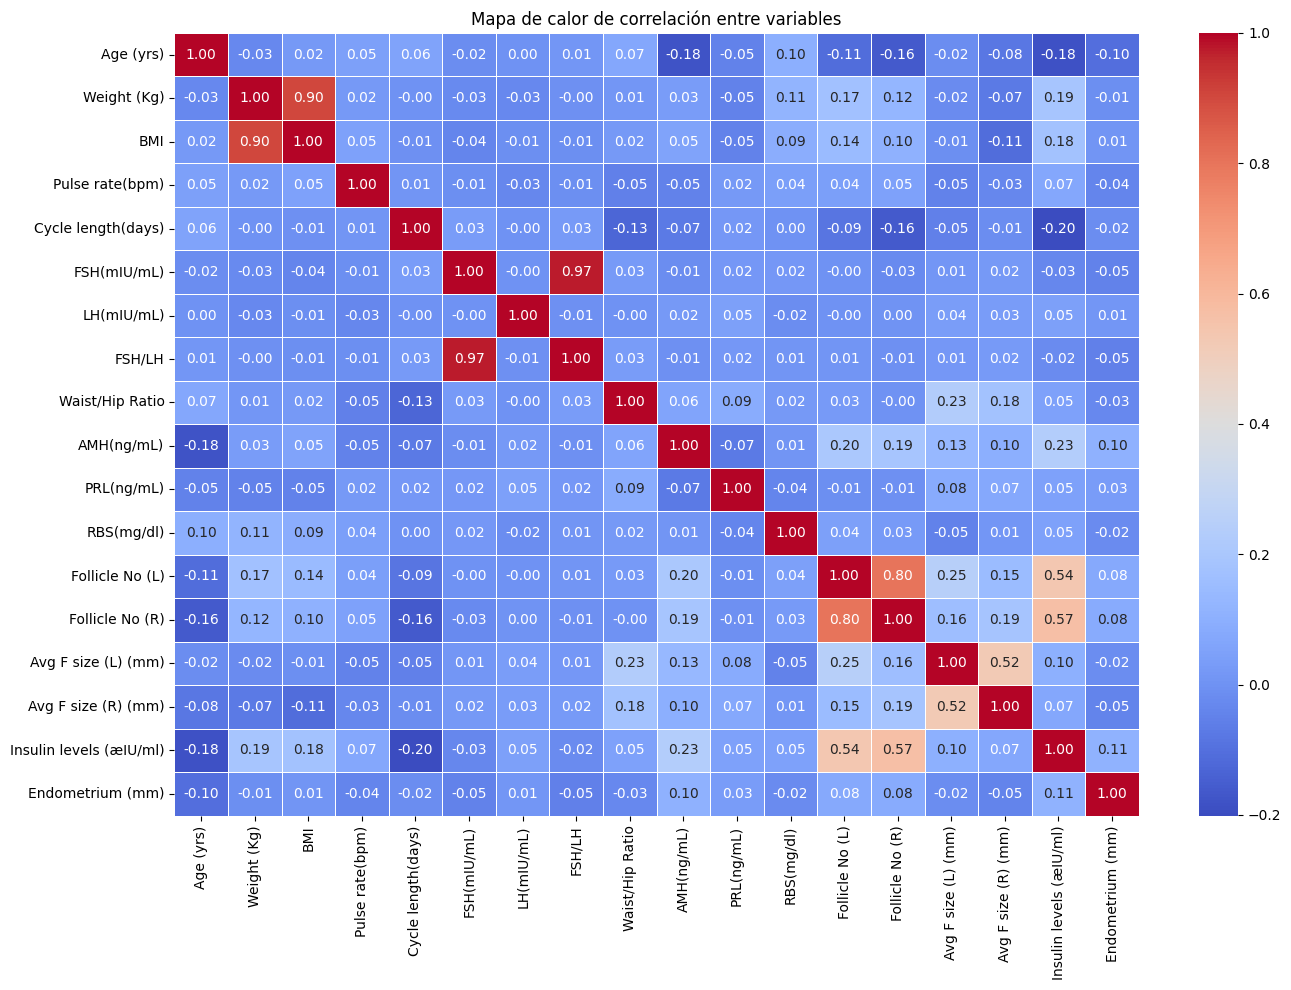

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

columnas = [
    'Age (yrs)',
    'Weight (Kg)',
    'BMI',
    'Pulse rate(bpm)',
    'Cycle length(days)',
    'FSH(mIU/mL)',
    'LH(mIU/mL)',
    'FSH/LH',
    'Waist/Hip Ratio',
    'AMH(ng/mL)',
    'PRL(ng/mL)',
    'RBS(mg/dl)',
    'Follicle No (L)',
    'Follicle No (R)',
    'Avg F size (L) (mm)',
    'Avg F size (R) (mm)',
    'Insulin levels (æIU/ml)',
    'Endometrium (mm)'
]



datos = df[columnas]



correlacion = datos.corr()

#MAPA DE CALOR
plt.figure(figsize=(14,10))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)


plt.title('Mapa de calor de correlación entre variables')

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()



plt.show()

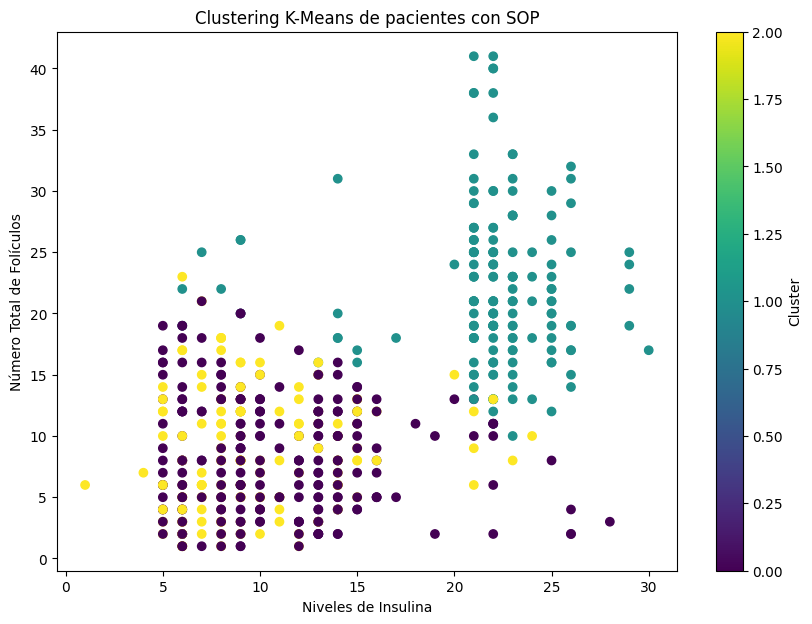

Pacientes por cluster:

Cluster
0    228
1    171
2    142
Name: count, dtype: int64


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#VARIABLES

columnas = [
    'BMI',
    'Insulin levels (æIU/ml)',
    'Follicle No (L)',
    'Follicle No (R)',
    'AMH(ng/mL)',
    'Waist/Hip Ratio'
]

datos = df[columnas]

#ELIMINA VALORES FALTANTES
datos = datos.dropna()


scaler = StandardScaler()
#NORMALIZA LOS DATOS
datos_normalizados = scaler.fit_transform(datos)

#  Aplicar K-Means Clustering

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(datos_normalizados)


# Agregar clusters al dataframe


datos['Cluster'] = clusters

#  Visualización


plt.figure(figsize=(10,7))

plt.scatter(
    datos['Insulin levels (æIU/ml)'],
    datos['Follicle No (L)'] + datos['Follicle No (R)'],
    c=datos['Cluster']
)

# Etiquetas


plt.xlabel('Niveles de Insulina')
plt.ylabel('Número Total de Folículos')

plt.title('Clustering K-Means de pacientes con SOP')

plt.colorbar(label='Cluster')

plt.show()

=

print("Pacientes por cluster:\n")

print(datos['Cluster'].value_counts())

In [ ]:
#